# PL player value predictor: exploration and experiments

This notebook walks through the data, the model, and the experiments behind the
choices in `backend/`. It is meant to be read top to bottom, and every result is
recomputed from the code in the repo, so it stays honest as the pipeline changes.

**Before running:** build the dataset with `python -m backend.sources.build_dataset`
(no API key needed; see the README).

Contents:
1. The data
2. What drives market value
3. The model and how well it does
4. Experiment log: what helped, what didn't
5. Who does the model think is over- or under-valued?

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from backend.config import PROCESSED_DATASET_PATH
from backend.features import CATEGORICAL_FEATURES, NUMERIC_FEATURES, add_derived_features
from backend.model import build_pipeline, cross_validate_model, fit_pipeline, value_weights

pd.set_option("display.width", 140)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

raw = pd.read_csv(PROCESSED_DATASET_PATH)
df = add_derived_features(raw)
print(f"{len(df)} players, {df.club.nunique()} clubs")

540 players, 20 clubs


## 1. The data

One row per player in a current Premier League squad. Two public sources, joined by name:

| Source | Gives us |
|---|---|
| Transfermarkt (scraped) | market value (the target), age, position, club |
| FPL API (bootstrap) | the club list, this season's minutes and starts, xG/xA, defensive stats |
| FPL season archive (vaastav) | minutes, starts, goals, assists and xG/xA for each past PL season |
| Understat | the same for the other big European leagues, for players new to the PL |
| Transfermarkt datasets (Kaggle, optional) | what a club last paid for the player |

None of them needs an API key. Past PL seasons come from a community archive of the FPL
API — one CSV per season rather than one request per player, which also reaches players
who aren't in *this* season's FPL game and would otherwise look like newcomers.

This project used to pull goals from football-data.org as well. It was dropped: its
top-scorers feed missed half the squad (defenders, keepers), and once FPL history was in,
removing it changed cross-validated error by less than one standard error.

In [2]:
raw.head(8)

,name,position,age,nationality,club,market_value_eur,contract_expiry,fpl_team,fpl_minutes,fpl_starts,...,has_nonpl_record,nonpl_recent_minutes,nonpl_recent_available_minutes,cl_minutes_last,us_minutes,us_xgchain,transfer_fee_eur,transfer_fee_date,has_transfer_fee,transfer_fee_years
0,David Raya,Goalkeeper,31,Spain,Arsenal,30000000.0,2028-06-30,Arsenal,450,5,...,0,0,3420,1170,13050,22.470,31900000.0,2024-07-04,1,2.22
1,Illan Meslier,Goalkeeper,26,France,Arsenal,8000000.0,2028-06-30,Arsenal,0,0,...,0,0,3420,0,3060,1.499,6500000.0,2020-07-27,1,6.16
2,Kepa Arrizabalaga,Goalkeeper,31,Spain,Arsenal,5000000.0,2028-06-30,Arsenal,0,0,...,1,0,3420,90,0,0.000,5800000.0,2025-07-01,1,1.23
3,William Saliba,Centre-Back,25,France,Arsenal,100000000.0,2030-06-30,Arsenal,0,0,...,0,0,3420,990,11491,51.696,30000000.0,2019-07-25,1,7.17
4,Gabriel,Centre-Back,28,Brazil,Arsenal,75000000.0,2029-06-30,Arsenal,450,5,...,1,0,3420,882,11590,47.231,26000000.0,2020-09-01,1,6.06
5,Piero Hincapié,Centre-Back,24,Ecuador,Arsenal,50000000.0,2031-06-30,Arsenal,32,0,...,1,90,3060,574,8497,35.877,40000000.0,2026-07-01,1,0.23
6,Ezri Konsa,Centre-Back,28,England,Arsenal,45000000.0,NaN,Arsenal,281,3,...,0,0,3420,0,12385,44.678,59600000.0,2026-07-01,1,0.23
7,Cristhian Mosquera,Centre-Back,22,Spain,Arsenal,40000000.0,2030-06-30,Arsenal,168,2,...,1,0,3420,493,7493,21.720,15000000.0,2025-07-24,1,1.17


### Coverage matters more than it looks

A top-scorers feed only lists players with a goal or assist, so most defenders and keepers
would have *no* stats rather than zero stats. The FPL per-player history doesn't have that
problem: it covers everyone who was in the game. That's why it's the most useful source here.

Its own gap is different: a quarter of the squad (signings from abroad, academy players) has
no PL history at all. Understat fills part of that from the other big leagues — but not
Portugal, the Championship or the Eredivisie, so about half of those players still have no
record anywhere. `has_any_history` flags them, and they remain the biggest source of error.

In [3]:
coverage = pd.DataFrame(
    {
        "has FPL record": raw.has_fpl_record.mean(),
        "played minutes this season": (raw.fpl_minutes > 0).mean(),
        "has past-season PL history": raw.has_hist_record.mean(),
        "has non-PL record (Understat)": raw.has_nonpl_record.mean(),
        "has history from either source": ((raw.has_hist_record == 1) | (raw.has_nonpl_record == 1)).mean(),
    },
    index=["share of dataset"],
).T
coverage.style.format("{:.0%}")

,share of dataset
has FPL record,98%
played minutes this season,76%
has past-season PL history,79%
has non-PL record (Understat),35%
has history from either source,90%


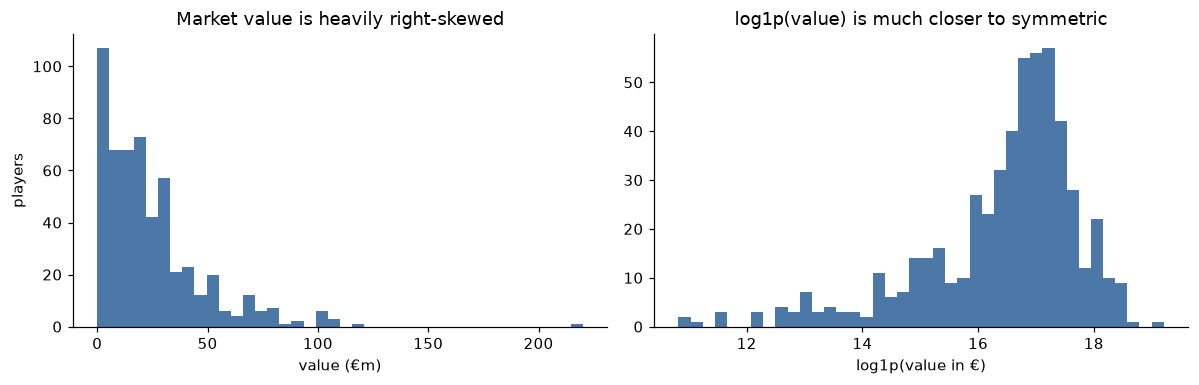

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(df.market_value_eur / 1e6, bins=40, color="#4c78a8")
axes[0].set(title="Market value is heavily right-skewed", xlabel="value (€m)", ylabel="players")
axes[1].hist(np.log1p(df.market_value_eur), bins=40, color="#4c78a8")
axes[1].set(title="log1p(value) is much closer to symmetric", xlabel="log1p(value in €)")
fig.tight_layout()

The skew is why the target is `log1p(value)`. A side effect: the model minimises *relative*
error, which matters in section 4.

## 2. What drives market value

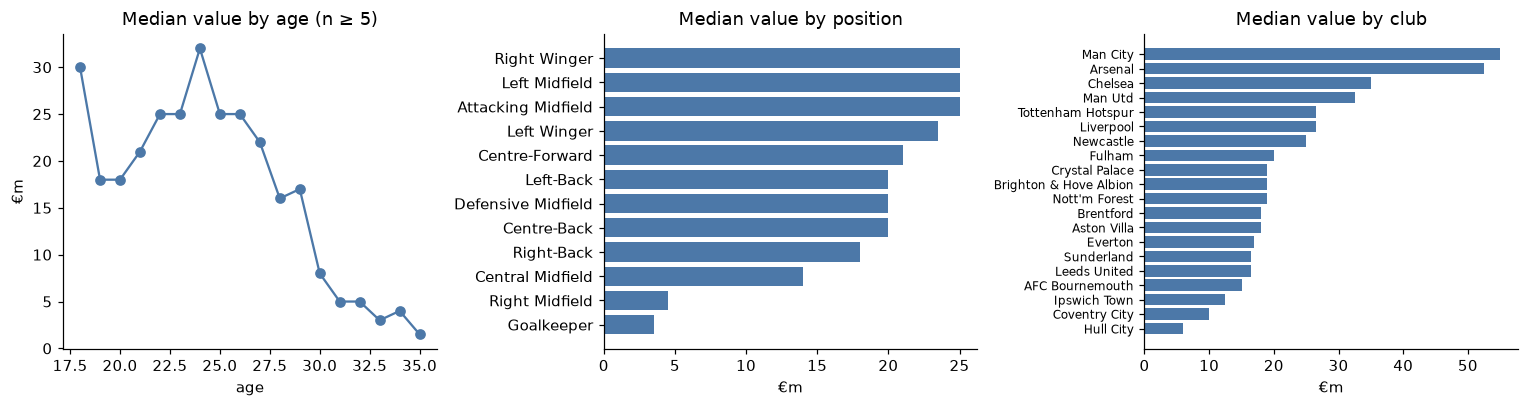

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

by_age = df.groupby("age").market_value_eur.agg(["median", "size"])
by_age = by_age[by_age["size"] >= 5]
axes[0].plot(by_age.index, by_age["median"] / 1e6, "o-", color="#4c78a8")
axes[0].set(title="Median value by age (n ≥ 5)", xlabel="age", ylabel="€m")

order = df.groupby("position").market_value_eur.median().sort_values()
axes[1].barh(order.index, order / 1e6, color="#4c78a8")
axes[1].set(title="Median value by position", xlabel="€m")

order = df.groupby("club").market_value_eur.median().sort_values()
axes[2].barh([c.replace(" FC", "") for c in order.index], order / 1e6, color="#4c78a8")
axes[2].set(title="Median value by club", xlabel="€m")
axes[2].tick_params(axis="y", labelsize=8)
fig.tight_layout()

Value peaks in the mid-20s and falls either side, so a straight line in age is the wrong
shape. That's why the model has `age_squared`. Club matters a lot too, since the same
player is worth more at a bigger club.

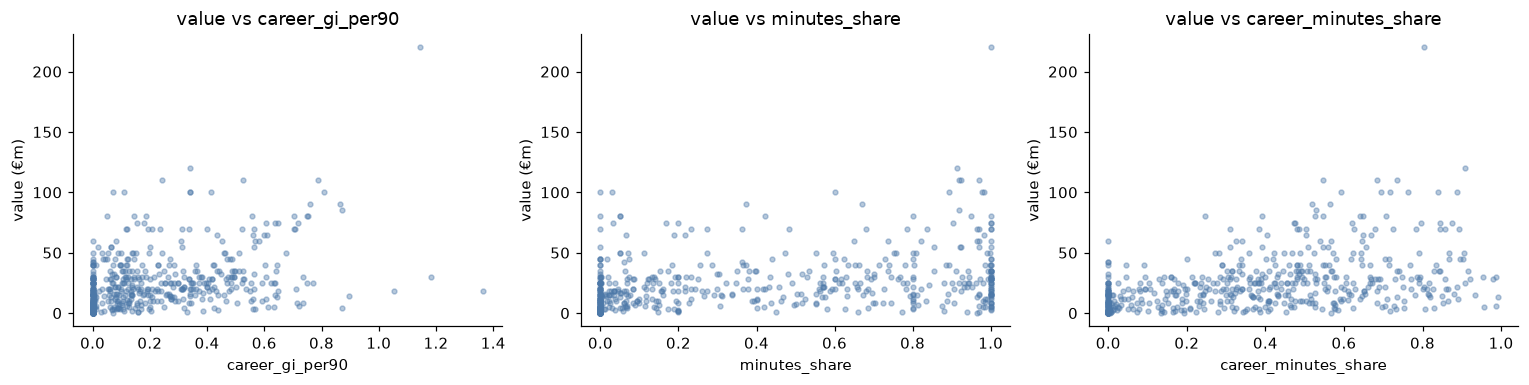

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, col in zip(axes, ["career_gi_per90", "minutes_share", "career_minutes_share"]):
    ax.scatter(df[col], df.market_value_eur / 1e6, s=10, alpha=0.4, color="#4c78a8")
    ax.set(xlabel=col, ylabel="value (€m)", title=f"value vs {col}")
fig.tight_layout()

Scoring rate only matters for the minority who have one (most of the dataset sits near zero).
The two playing-time features separate regulars from squad players across *all* positions.
`career_minutes_share` (past seasons) is the stronger of the two: it's a settled picture rather
than five gameweeks of noise, and a 0 there usually means genuinely new to the league rather
than merely rotated.

## 3. The model and how well it does

In [7]:
print("Numeric features:    ", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)
print()
print("Pipeline: StandardScaler on numeric + one-hot on categorical -> LinearRegression")

Numeric features:     ['age', 'age_squared', 'age_past_23', 'age_past_29', 'has_fpl_record', 'minutes_share', 'has_hist_record', 'has_any_history', 'career_minutes_share', 'career_gi_per90', 'recent_minutes_share', 'has_transfer_fee', 'log_transfer_fee', 'idle_this_season', 'idle_x_career', 'idle_x_fee', 'youth_x_recent', 'older_x_career', 'years_since_fee', 'backup_keeper', 'gi_x_career', 'cl_matches_last', 'below_career', 'xgchain_vs_position', 'has_quality_record']
Categorical features: ['position', 'club']

Pipeline: StandardScaler on numeric + one-hot on categorical -> LinearRegression


In [8]:
metrics = cross_validate_model(df)
pd.Series(
    {
        "R² (log value)": f"{metrics['cv_r2_log']:.3f}",
        "MAE": f"€{metrics['cv_mae_eur'] / 1e6:.1f}m",
        "RMSE": f"€{metrics['cv_rmse_eur'] / 1e6:.1f}m",
        "MAE, top 10% most valuable": f"€{metrics['cv_top_decile_mae_eur'] / 1e6:.1f}m",
        "predicted/actual, top 10%": f"{metrics['cv_top_decile_ratio']:.2f}  (1.0 = unbiased)",
    },
    name="5-fold cross-validation",
).to_frame()

,5-fold cross-validation
R² (log value),0.831
MAE,€5.9m
RMSE,€8.5m
"MAE, top 10% most valuable",€13.1m
"predicted/actual, top 10%",0.92 (1.0 = unbiased)


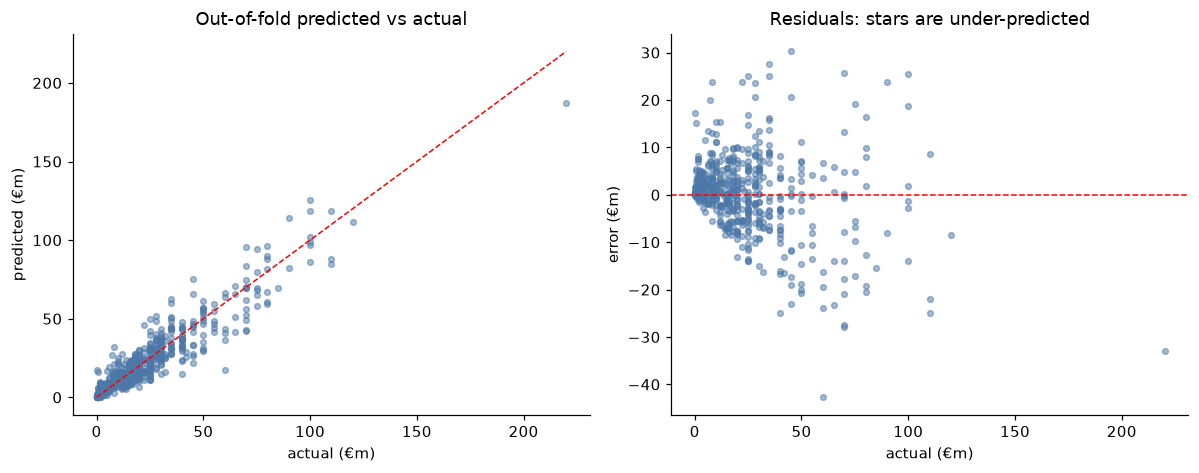

In [9]:
# Out-of-fold predictions: every player is predicted by a model that never saw them.
from sklearn.model_selection import KFold

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = np.log1p(df.market_value_eur)
oof = pd.Series(0.0, index=df.index)
for tr, te in KFold(5, shuffle=True, random_state=42).split(X):
    oof.iloc[te] = fit_pipeline(build_pipeline(), X.iloc[tr], y.iloc[tr]).predict(X.iloc[te])
df["predicted_eur"] = np.expm1(oof)
df["error_eur"] = df.predicted_eur - df.market_value_eur

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].scatter(df.market_value_eur / 1e6, df.predicted_eur / 1e6, s=14, alpha=0.5, color="#4c78a8")
lim = df.market_value_eur.max() / 1e6
axes[0].plot([0, lim], [0, lim], "r--", lw=1)
axes[0].set(xlabel="actual (€m)", ylabel="predicted (€m)", title="Out-of-fold predicted vs actual")
axes[1].scatter(df.market_value_eur / 1e6, df.error_eur / 1e6, s=14, alpha=0.5, color="#4c78a8")
axes[1].axhline(0, color="r", ls="--", lw=1)
axes[1].set(xlabel="actual (€m)", ylabel="error (€m)", title="Residuals: stars are under-predicted")
fig.tight_layout()

The fan shape on the right is the model's main weakness: the more valuable the player,
the more it under-predicts. Regression to the mean explains part of it. The rest is
"star premium" that on-pitch stats in this dataset simply don't capture.

## 4. Experiment log

Everything below is cross-validated (5 folds × 3 repeats), because a single 80/20 split at
this dataset size swings by ~0.1 R². The harness re-fits the pipeline from scratch each fold.

In [10]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

gw = df.fpl_gameweeks.clip(lower=1)
df["xgi_per_gw"] = (df.fpl_xg + df.fpl_xa) / gw
df["def_per_gw"] = df.fpl_defensive_contribution / gw

seasons = df.hist_seasons.clip(lower=1)
mins = df.hist_minutes.clip(lower=1)
df["hist_starts_per_season"] = df.hist_starts / seasons
df["hist_gi_total"] = df.hist_goals + df.hist_assists
df["hist_xgi_per90"] = (df.hist_xg + df.hist_xa) / mins * 90
df["hist_minutes_share"] = df.hist_minutes / (seasons * 3420)
df["hist_gi_per90"] = (df.hist_goals + df.hist_assists) / mins * 90
df["nonpl_minutes_share"] = df.nonpl_minutes / df.nonpl_available_minutes.clip(lower=1)
df["nonpl_gi_per90"] = (
    (df.nonpl_goals + df.nonpl_assists) / df.nonpl_minutes.clip(lower=1) * 90
)
df["starts_share"] = df.fpl_starts / gw
# "PL history only" = the model before Understat was added
pl_only = [f for f in NUMERIC_FEATURES
           if f not in ("career_minutes_share", "career_gi_per90", "has_any_history")]
pl_only = pl_only + ["hist_minutes_share", "hist_gi_per90"]
newcomer = (df.has_hist_record == 0).to_numpy()

values = df.market_value_eur.to_numpy()
y_log = np.log1p(values)
top = values >= np.quantile(values, 0.9)


def cv_eval(numeric, regressor=None, weighted=True, categorical=CATEGORICAL_FEATURES,
            n_repeats=3, target_power=None):
    """Repeated K-fold; returns mean log-R², euro MAE, top-decile MAE and ratio."""
    rows = []
    cv = RepeatedKFold(n_splits=5, n_repeats=n_repeats, random_state=0)
    for tr, te in cv.split(df):
        pre = ColumnTransformer([
            ("n", StandardScaler(), numeric),
            ("c", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical),
        ])
        pipe = Pipeline([("p", pre), ("r", clone(regressor) if regressor is not None else LinearRegression())])
        cols = numeric + categorical
        fit_kw = {"r__sample_weight": value_weights(values[tr])} if weighted else {}
        pipe.fit(df.iloc[tr][cols], y_log[tr], **fit_kw)
        pred = np.expm1(pipe.predict(df.iloc[te][cols]))
        err = np.abs(pred - values[te])
        t = top[te]
        nb = newcomer[te]
        rows.append([
            1 - ((np.log1p(pred) - y_log[te]) ** 2).sum() / ((y_log[te] - y_log[te].mean()) ** 2).sum(),
            err.mean() / 1e6,
            err[t].mean() / 1e6,
            (pred[t] / values[te][t]).mean(),
            err[nb].mean() / 1e6,
        ])
    r = np.nanmean(rows, axis=0)
    return {"R² (log)": r[0], "MAE €m": r[1], "top-10% MAE €m": r[2],
            "new-to-PL MAE €m": r[4], "top-10% pred/actual": r[3]}


def table(results):
    return pd.DataFrame(results).T.style.format(
        {"R² (log)": "{:.3f}", "MAE €m": "{:.2f}", "top-10% MAE €m": "{:.1f}",
         "new-to-PL MAE €m": "{:.2f}", "top-10% pred/actual": "{:.2f}"}
    ).background_gradient(subset=["MAE €m"], cmap="RdYlGn_r")

### 4a. Feature engineering (linear regression, sqrt-value weighting)

In [11]:
base = ["age", "goals", "assists", "penalties", "appearances"]
this_season = ["has_fpl_record", "minutes_share", "starts_share"]
history = ["has_hist_record", "hist_minutes_share"]
no_rate = [f for f in NUMERIC_FEATURES if f != "career_gi_per90"]
df["career_gi_total"] = np.where(df.has_hist_record == 1,
                                 df.hist_goals + df.hist_assists,
                                 df.nonpl_goals + df.nonpl_assists)

fee = ["has_transfer_fee", "log_transfer_fee", "years_since_fee"]
idle = ["idle_this_season", "idle_x_career", "idle_x_fee"]
regulars = ["youth_x_recent", "older_x_career"]
extra = ["backup_keeper", "gi_x_career"]
europe = ["cl_matches_last"]
interrupted = ["below_career"]
quality = ["xgchain_vs_position", "has_quality_record"]
core = [f for f in NUMERIC_FEATURES if f not in fee + idle + regulars + extra + europe + interrupted + quality]

sets = {
    "1. age + position + club": ["age"],
    "2. + age² (value peaks mid-20s)": ["age", "age_squared"],
    "3. + this season's playing time": ["age", "age_squared"] + this_season,
    "4. + past seasons, career and newest": core,
    "5. + what the club last paid, and when": core + fee,
    "6. + reading 'not playing' properly": core + fee + idle,
    "7. + young and older regulars": core + fee + idle + regulars,
    "8. + backup keepers, output over a career": core + fee + idle + regulars + extra,
    "9. + Champions League minutes last season": core + fee + idle + regulars + extra + europe,
    "10. + a season below one's own level": core + fee + idle + regulars + extra + europe + interrupted,
    "11. + attacking involvement vs position (current)": NUMERIC_FEATURES,
    "--- rejected alternatives ---": NUMERIC_FEATURES,
    "12. starts_share (0.98 correlated with minutes)": NUMERIC_FEATURES + ["starts_share"],
    "13. non-PL record as its OWN feature": NUMERIC_FEATURES + ["has_nonpl_record", "nonpl_minutes_share", "nonpl_gi_per90"],
    "14. goal/assist TOTALS instead of the rate": [f for f in no_rate if f != "gi_x_career"] + ["career_gi_total"],
    "15. + past-season xG+xA per 90": NUMERIC_FEATURES + ["hist_xgi_per90"],
    "16. + this season's xG/xA": NUMERIC_FEATURES + ["xgi_per_gw"],
    "17. + this season's defensive stats": NUMERIC_FEATURES + ["def_per_gw"],
    "18. + FPL price": NUMERIC_FEATURES + ["fpl_price"],
    "19. + FPL bonus points per 90 (PL record only)": NUMERIC_FEATURES + ["career_bps_per90", "recent_bps_per90"],
}
table({name: cv_eval(cols) for name, cols in sets.items()})

,R² (log),MAE €m,top-10% MAE €m,new-to-PL MAE €m,top-10% pred/actual
1. age + position + club,0.255,13.45,31.7,9.50,0.66
2. + age² (value peaks mid-20s),0.449,11.29,28.0,9.44,0.71
3. + this season's playing time,0.620,9.44,24.7,9.03,0.80
"4. + past seasons, career and newest",0.730,7.09,16.1,6.61,0.90
"5. + what the club last paid, and when",0.753,6.83,15.3,6.28,0.91
6. + reading 'not playing' properly,0.781,6.39,12.9,6.43,0.91
7. + young and older regulars,0.785,6.27,12.2,6.21,0.91
"8. + backup keepers, output over a career",0.815,6.18,11.9,6.13,0.91
9. + Champions League minutes last season,0.821,6.06,12.5,5.55,0.92
10. + a season below one's own level,0.821,6.00,12.5,5.58,0.92


What to take from this:

- **What a club paid matters as much as what a player did** (row 5). Every other
  feature describes the pitch, which left the model blind to an expensive signing
  who has barely played. When it was paid matters too: a fee from last summer
  says more than one from 2020.
- **"Not playing" needed a product term** (row 6). A few gameweeks in, missing the
  start of a season was being read as strong evidence; multiplying that flag by
  the career share and by the fee tells the model to lean on history instead. A
  linear model cannot form a product of its own features, so it had to be built.
- **Regulars age differently** (row 7). A teenager who was a regular last season is
  rare and priced like it, and after 29 the decline is gentler for someone who has
  kept his place. Both are products of age and minutes, built for the same reason.
- **Not playing means different things in goal** (row 8). With no minutes and no fee, a
  keeper is a backup worth next to nothing, while an outfield player the same age may be
  a prospect; one flag says so. Goals+assists per 90 times career minutes separates a
  regular who produces from a cameo that happened to score. Together they take the
  median player under €1m from 4.4× the market to 2.5×.
- **Last season's Champions League** (row 9) says what domestic minutes cannot: that a
  player is trusted in the games that decide a season. It lifts the very top most -
  Haaland from 0.82 of his market value to 0.91 - at a small cost among the rest of the
  dearest tenth, since it moves value toward the clubs that played in it.
- **A season below one's own level** (row 10) is more often an interruption than a
  demotion: an injury-hit season (Isak: 20% of minutes against a career 53%) was being
  read as a lost place. Found by a reader's second round of labels.
- **Attacking involvement, against the position** (row 11): Understat's xGChain per 90,
  divided by the position group's average. It covers the PL and the five other big leagues
  the same way, so it is the quality score that is fair to players arriving from abroad -
  unlike FPL's bonus points (row 19).
- **Age² and playing time are the wins.** Age² fixes the wrong-shaped age curve; the
  playing-time features tell the model who actually plays. Past-season minutes (row 4) is the
  single biggest addition, and it cuts top-decile error by about a fifth.
- **A fallback beats an extra column** (row 11 vs row 13). Adding the non-PL record as its own
  feature made things *worse*: it's zero for most of the squad, so it mostly added noise.
  Folding it into the same feature as the PL history — PL record where it exists, otherwise
  the non-PL one — improved everything, and cut new-to-PL error by ~11%.
- **Rates beat totals** (row 11 vs row 14). Goal and assist *totals* mostly restate how much a
  player played — information the model already has. The same output expressed *per 90
  minutes* is independent of playing time. The gap is smaller than it was before the non-PL
  fallback went in, but it still favours the rate.
- **Expected goals add nothing on top of actual output** (row 15), and this season's stats are
  still too noisy at five gameweeks (rows 16-17). Both worth re-testing later in the season.
- **`fpl_price` is rejected** (row 18). It lifts log-R² but *worsens* euro error, especially
  for stars: its range is compressed, and it's FPL's own valuation rather than performance.

- **FPL bonus points per 90 are rejected despite the numbers** (row 19). They lower the
  aggregate error, but exist only for players with a PL record, so a newcomer from abroad has
  no quality score while everyone he is compared with does - and players flagged as too cheap
  (Bouaddi, Barcola) fell further. A fair quality score would have to cover every league.

(The "rejected alternatives" row repeats the current model as a reference line.)

### 4b. Does a fancier model help?

In [12]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

def rf():
    return RandomForestRegressor(300, min_samples_leaf=3, random_state=0, n_jobs=-1)

def gb():
    return GradientBoostingRegressor(n_estimators=200, max_depth=2, learning_rate=0.05,
                                     subsample=0.8, random_state=0)

cur = NUMERIC_FEATURES
table({
    "Linear, √value weights (current)": cv_eval(cur, n_repeats=2),
    "Linear, unweighted": cv_eval(cur, weighted=False, n_repeats=2),
    "Random forest, √value weights": cv_eval(cur, rf(), n_repeats=2),
    "Random forest, unweighted": cv_eval(cur, rf(), weighted=False, n_repeats=2),
    "Gradient boosting, √value weights": cv_eval(cur, gb(), n_repeats=2),
    "Gradient boosting, unweighted": cv_eval(cur, gb(), weighted=False, n_repeats=2),
})

,R² (log),MAE €m,top-10% MAE €m,new-to-PL MAE €m,top-10% pred/actual
"Linear, √value weights (current)",0.825,5.87,12.5,5.63,0.90
"Linear, unweighted",0.825,6.71,15.3,5.73,0.93
"Random forest, √value weights",0.732,7.46,23.6,6.37,0.72
"Random forest, unweighted",0.806,7.33,25.7,6.01,0.69
"Gradient boosting, √value weights",0.805,7.01,22.1,5.95,0.78
"Gradient boosting, unweighted",0.825,7.24,23.5,6.23,0.74


Every model gets the same features and the same choice of weighting. What to take from this:

- **Linear with √value weights has the lowest euro error**, both overall and for the top 10%.
- **Gradient boosting ties the linear model on log-R² only when both are unweighted**
  (~0.63), and is much more conservative on stars (pred/actual ≈ 0.7 vs ≈ 0.85).
- **Random forest is worst throughout.**

With ~540 rows the extra flexibility of trees isn't buying anything on the metric we care about,
so the simple, explainable model stays. Gradient boosting is the one to revisit if the dataset
grows (e.g. multi-season data).

### 4c. The star-player problem

Plain log-value regression treats a 10% error on a €1m player the same as on a €100m
player, so the many cheap players outvote the few stars. Weighting each player by
√value in training rebalances that:

In [13]:
table({
    "unweighted": cv_eval(NUMERIC_FEATURES, weighted=False),
    "weight ∝ √value (current)": cv_eval(NUMERIC_FEATURES),
})

,R² (log),MAE €m,top-10% MAE €m,new-to-PL MAE €m,top-10% pred/actual
unweighted,0.825,6.77,15.5,5.74,0.94
weight ∝ √value (current),0.827,5.89,12.4,5.61,0.91


Weighting cuts euro error both overall (€9.9m → €9.3m) and on the top 10% (€29m → €25m). It's a
trade-off, not a free win: log-R² drops (0.62 → 0.58), and the average top-10% pred/actual
ratio is actually slightly *better* unweighted (0.89 vs 0.86). We optimise the euro error
because that's what "how far off is the estimate" means to a user.

The model is still conservative about the very top. Removing that bias with a smearing correction
made the *overall* error worse in earlier experiments (€10.3m → €11.6m), so it's not adopted. The
remaining gap is probably a data problem (no brand or reputation information), not a modelling one.

## 5. Who does the model think is over- or under-valued?

Out-of-fold predictions (section 3), so each player is scored by a model that never saw them.
A large gap doesn't mean Transfermarkt is *wrong*. It means the player is worth more (or
less) than their on-pitch numbers and profile alone would suggest, e.g. a hyped youngster, or
a defender whose value is in things these stats don't measure.

**Read the "history" column**: the number of past PL seasons the model had for that player.
A 0 means a new arrival (or an academy player), so the model is working from age, position,
club and a few gameweeks only, and tends to under-predict them. Several of the biggest
"worth less" gaps below are that artefact rather than a real signal.

In [14]:
cols = ["name", "club", "position", "age", "hist_seasons", "market_value_eur", "predicted_eur"]
gap = df[cols].assign(gap_pct=(df.predicted_eur / df.market_value_eur - 1) * 100)
big = gap[gap.market_value_eur >= 15e6]  # ignore tiny values, where % gaps are meaningless

def show(frame):
    return frame.assign(
        market_value_eur=(frame.market_value_eur / 1e6).round(1),
        predicted_eur=(frame.predicted_eur / 1e6).round(1),
        gap_pct=frame.gap_pct.round(0),
    ).rename(columns={"market_value_eur": "actual €m", "predicted_eur": "predicted €m",
                      "gap_pct": "gap %", "hist_seasons": "history"}
    ).reset_index(drop=True)

print("Model thinks these are worth MORE than Transfermarkt says (players ≥ €15m):")
display(show(big.sort_values("gap_pct", ascending=False).head(10)))
print("Model thinks these are worth LESS:")
display(show(big.sort_values("gap_pct").head(10)))

Model thinks these are worth MORE than Transfermarkt says (players ≥ €15m):


,name,club,position,age,history,actual €m,predicted €m,gap %
0,Mathys Tel,Tottenham Hotspur,Left Winger,21,2,22.0,45.8,108.0
1,Lewis Miley,Newcastle,Central Midfield,20,4,25.0,50.0,100.0
2,Alejandro Garnacho,Aston Villa,Left Winger,22,4,28.0,51.5,84.0
3,Milos Kerkez,Liverpool,Left-Back,22,3,35.0,62.6,79.0
4,Wesley Fofana,Chelsea,Centre-Back,25,4,28.0,48.6,74.0
5,Malo Gusto,Chelsea,Right-Back,23,3,35.0,60.1,72.0
6,Diego Gómez,Brighton & Hove Albion,Central Midfield,23,2,25.0,41.9,68.0
7,Gianluigi Donnarumma,Man City,Goalkeeper,27,1,45.0,75.2,67.0
8,Igor Jesus,Nott'm Forest,Centre-Forward,25,1,25.0,39.7,59.0
9,Wilson Odobert,Tottenham Hotspur,Left Winger,21,3,18.0,27.8,55.0


Model thinks these are worth LESS:


,name,club,position,age,history,actual €m,predicted €m,gap %
0,Luka Vuskovic,Brighton & Hove Albion,Centre-Back,19,1,60.0,17.3,-71.0
1,Jaden Philogene,Ipswich Town,Left Winger,24,3,20.0,6.8,-66.0
2,Jarrad Branthwaite,Everton,Centre-Back,24,4,40.0,15.0,-62.0
3,Jean-Mattéo Bahoya,Leeds United,Left Winger,21,0,25.0,11.1,-56.0
4,Christos Mouzakitis,Hull City,Central Midfield,19,0,25.0,11.1,-56.0
5,Chris Rigg,Sunderland,Attacking Midfield,19,1,25.0,11.4,-54.0
6,Tino Livramento,Newcastle,Right-Back,23,4,45.0,21.9,-51.0
7,Hayden Hackney,Everton,Defensive Midfield,24,0,32.0,15.8,-51.0
8,Promise David,Brighton & Hove Albion,Centre-Forward,25,0,17.0,8.4,-50.0
9,Antonee Robinson,Fulham,Left-Back,29,4,22.0,11.0,-50.0


## Where to go next

- **Re-test the current-season features** as more gameweeks are played. Right now the past
  seasons carry the signal and this season is mostly noise; that balance should shift.
- **More history does *not* help.** The archive makes extra seasons nearly free, but going
  back to 2018 lowers R² from 0.673 to 0.655: old form says little about today's value.
- **The rest of the new arrivals.** Understat covers the big five leagues; Portugal, the
  Championship and the Eredivisie it does not, so about half of the players new to the PL
  still have no record anywhere. Transfermarkt's own per-player pages would cover them, but
  they are no longer server-rendered, so scraping them needs a browser.
- **Transfer fees closed much of the "star premium" gap** and are now in the model.
  Contract length was tested alongside them and does nothing (+1.0 standard error).
- **Historical valuations do not help.** Transfermarkt has published ~9,800 valuations
  for these players over twenty years — eighteen times the training data. Trained on all
  of it and tested on 2026, MAE is €9.48m; trained on 2025 alone, €8.92m. Old valuations
  teach the wrong relationship. Volume does help at constant recency (540 random rows
  give €10.98m against €8.92m for 1,417 rows from 2025), so it is the age of the data
  that hurts, not the quantity.
- **Some of what looked like reputation was a stale file.** Bouaddi was under-predicted
  by a factor of three, apparently for want of a scouting report; in fact City had paid
  €95m for him after the Kaggle snapshot was taken. Each club's transfers page now
  supplies this season's fees. Young players the market prices highly who carry no fee
  at all — Mouzakitis, Philogene — are still under-predicted three- to four-fold: that
  part of the gap is reputation, and nothing we can reach measures it.